# Crop recommendation

Module A: compare classifiers using N, P, K, temperature, humidity, pH, and rainfall, then return the top three crop labels.
The dataset has 22 crops. This experiment measures label prediction; field suitability, yield, and profitability need separate evidence.

Use the project Python environment with `requirements-notebooks.txt` installed.

## Dataset

Source: [Atharva Ingle's Crop Recommendation Dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset),
version 1, publisher-listed Apache 2.0. It contains 2,200 rows, seven features, and 22 labels.
The publisher describes augmented rainfall, climate, and fertilizer data for India. The manifest records the CSV checksum.

Temperature is in °C, humidity in %, rainfall in mm, and pH is dimensionless.
N/P/K measurement units and the climate aggregation periods remain unresolved. Keep the original nutrient scale;
don't substitute a soil report or tomorrow's rainfall without a verified mapping.

There are no farm, district, season, or yield records for independent field validation.

In [3]:
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
import hashlib
import io
import json
import zipfile
import joblib
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay, top_k_accuracy_score)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "report/bonus_modules_sources.json").is_file())
MANIFEST = json.loads((ROOT / "report/bonus_modules_sources.json").read_text(encoding="utf-8"))
SOURCE = MANIFEST["crop_recommendation"]
DATA_PATH = ROOT / "data/crop_recommendation/raw/Crop_recommendation.csv"
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
SEED = 42
TRY_DOWNLOAD = True


## Load and inspect

Load the local CSV, or download version 1 if it is missing. If Kaggle requires a browser download,
save `Crop_recommendation.csv` in `data/crop_recommendation/raw/`.
The checksum check stops the run if the file differs from the recorded version.

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


{'rows': 2200, 'classes': 22, 'duplicates_removed': 0}


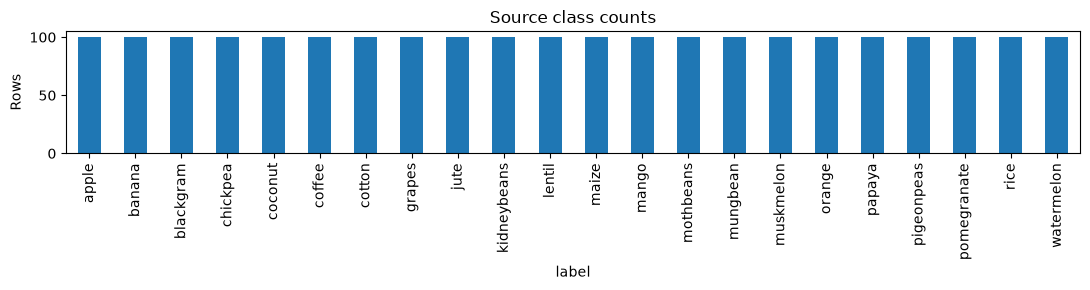

In [4]:
if not DATA_PATH.exists() and TRY_DOWNLOAD:
    try:
        response = requests.get(SOURCE["download_url"], timeout=(15, 60))
        response.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            members = [name for name in archive.namelist()
                       if name.rsplit("/", 1)[-1] == DATA_PATH.name]
            if len(members) != 1:
                raise ValueError("Expected exactly one Crop_recommendation.csv in the archive.")
            if archive.getinfo(members[0]).file_size > 10_000_000:
                raise ValueError("Unexpected dataset size.")
            raw = archive.read(members[0])
        if hashlib.sha256(raw).hexdigest() != SOURCE["sha256"]:
            raise ValueError("Downloaded CSV does not match the pinned source checksum.")
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        DATA_PATH.write_bytes(raw)
    except (requests.RequestException, zipfile.BadZipFile, ValueError) as exc:
        print(f"Automatic download unavailable: {exc}")

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Download version 1 from {SOURCE['source_page']} to {DATA_PATH}")
dataset_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
if dataset_sha256 != SOURCE["sha256"]:
    raise ValueError("Source hash mismatch. Restore the original version-1 CSV.")
data = pd.read_csv(DATA_PATH)
if list(data.columns) != FEATURES + ["label"] or len(data) != SOURCE["rows"]:
    raise ValueError("Unexpected source schema or row count.")
if data.isna().any().any():
    raise ValueError("Missing values require an explicit data-quality decision.")
data[FEATURES] = data[FEATURES].apply(pd.to_numeric, errors="raise")
if not np.isfinite(data[FEATURES].to_numpy()).all():
    raise ValueError("Non-finite feature values.")
if not data["label"].map(lambda value: isinstance(value, str) and bool(value.strip())).all():
    raise ValueError("Invalid crop labels.")
if sorted(data["label"].unique()) != SOURCE["labels"]:
    raise ValueError("Unexpected label vocabulary.")
if ((data[["N", "P", "K", "rainfall"]] < 0).any().any()
        or not data["humidity"].between(0, 100).all()
        or not data["ph"].between(0, 14).all()):
    raise ValueError("Invalid source ranges.")
conflicting = data.groupby(FEATURES, dropna=False)["label"].nunique().gt(1)
if conflicting.any():
    raise ValueError("Identical inputs have conflicting labels; inspect before splitting.")
duplicate_count = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
display(data.head(), data[FEATURES].describe())
print({"rows": len(data), "classes": data.label.nunique(), "duplicates_removed": duplicate_count})
data.label.value_counts().sort_index().plot.bar(figsize=(11, 3), title="Source class counts")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


## Split the data

Remove exact duplicates, then use stratified 60/20/20 train, validation, and test splits.
Preprocessing fits on training rows only. Related augmented records could still occur across splits;
without farm IDs, this is a within-dataset benchmark.

In [5]:
train, remainder = train_test_split(data, test_size=0.4, stratify=data.label, random_state=SEED)
validation, test = train_test_split(remainder, test_size=0.5,
                                  stratify=remainder.label, random_state=SEED)
splits = {"train": train, "validation": validation, "test": test}
for name, frame in splits.items():
    if set(frame.label) != set(SOURCE["labels"]):
        raise ValueError(f"Missing labels in {name}.")
assert set(train.index).isdisjoint(validation.index)
assert set(train.index).isdisjoint(test.index)
assert set(validation.index).isdisjoint(test.index)
training_ranges = train[FEATURES].agg(["min", "max"])
display(pd.DataFrame({name: frame.label.value_counts() for name, frame in splits.items()}))


,train,validation,test
label,,,
apple,60,20,20
banana,60,20,20
blackgram,60,20,20
chickpea,60,20,20
coconut,60,20,20
coffee,60,20,20
cotton,60,20,20
grapes,60,20,20
jute,60,20,20


## Train models

Compare a majority baseline, scaled logistic regression, Gaussian naive Bayes, and random forest.
Keep their settings fixed for this comparison. Scalers fit on training rows only.

In [6]:
models = {
    "majority": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "gaussian_naive_bayes": GaussianNB(),
    "random_forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                            random_state=SEED, n_jobs=2),
}
for name, estimator in models.items():
    estimator.fit(train[FEATURES], train.label)
    print(f"Fitted {name} on {len(train)} training rows.")


Fitted majority on 1320 training rows.
Fitted logistic_regression on 1320 training rows.
Fitted gaussian_naive_bayes on 1320 training rows.
Fitted random_forest on 1320 training rows.


## Validation comparison

Select by validation macro-F1. Top-three accuracy measures whether the recorded label appears among the candidates;
it doesn't establish that all three are suitable. Model scores are uncalibrated.

In [7]:
def evaluate(estimator, frame):
    predictions = estimator.predict(frame[FEATURES])
    probabilities = estimator.predict_proba(frame[FEATURES])
    return {
        "macro_f1": float(f1_score(frame.label, predictions, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(frame.label, predictions)),
        "top3_accuracy": float(top_k_accuracy_score(frame.label, probabilities, k=3,
                                                   labels=estimator.classes_)),
    }

validation_comparison = pd.DataFrame([
    {"model": name, **evaluate(estimator, validation)} for name, estimator in models.items()
]).sort_values(["macro_f1", "model"], ascending=[False, True]).reset_index(drop=True)
selected_name = validation_comparison.iloc[0]["model"]
selected_model = models[selected_name]
display(validation_comparison)
print("Selected:", selected_name)


,model,macro_f1,accuracy,top3_accuracy
0,random_forest,0.995452,0.995455,1.000000
1,gaussian_naive_bayes,0.995443,0.995455,1.000000
2,logistic_regression,0.972596,0.972727,1.000000
3,majority,0.003953,0.045455,0.136364


Selected: random_forest


## Test results

Evaluate the selected model on the held-out rows. Keep this set out of further tuning.
The exported model remains fitted on training rows only, matching the model evaluated here.

macro_f1         0.990869
accuracy         0.990909
top3_accuracy    1.000000
dtype: float64

,precision,recall,f1-score,support
apple,1.000000,1.000000,1.000000,20.000000
banana,1.000000,1.000000,1.000000,20.000000
blackgram,1.000000,1.000000,1.000000,20.000000
chickpea,1.000000,1.000000,1.000000,20.000000
coconut,1.000000,1.000000,1.000000,20.000000
coffee,1.000000,1.000000,1.000000,20.000000
cotton,1.000000,1.000000,1.000000,20.000000
grapes,1.000000,1.000000,1.000000,20.000000
jute,0.869565,1.000000,0.930233,20.000000
kidneybeans,1.000000,1.000000,1.000000,20.000000


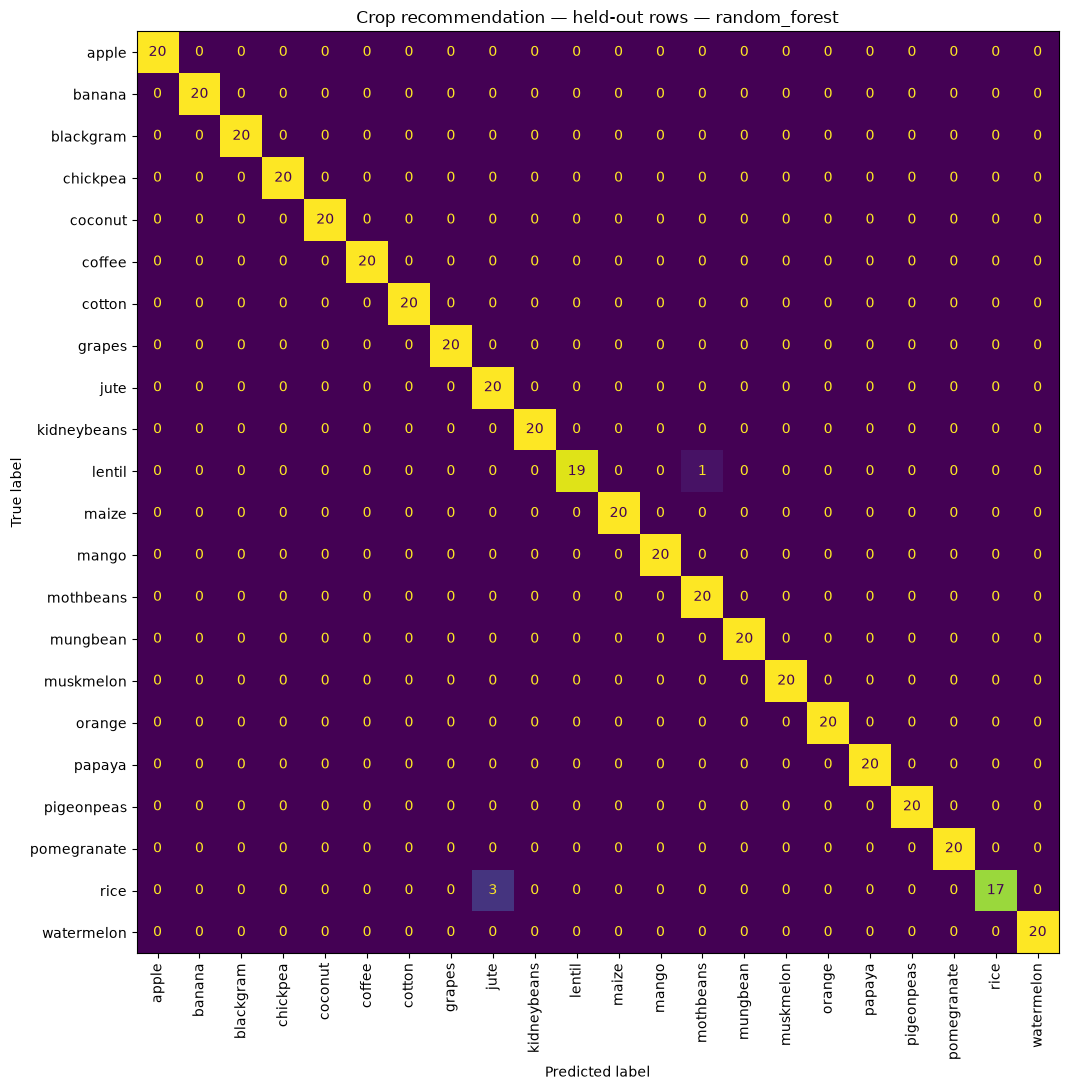

In [8]:
test_metrics = evaluate(selected_model, test)
test_predictions = selected_model.predict(test[FEATURES])
per_class = classification_report(test.label, test_predictions, labels=SOURCE["labels"],
                                  output_dict=True, zero_division=0)
display(pd.Series(test_metrics), pd.DataFrame(per_class).T)
fig, ax = plt.subplots(figsize=(12, 11))
ConfusionMatrixDisplay.from_predictions(test.label, test_predictions, labels=SOURCE["labels"],
                                       xticks_rotation=90, ax=ax, colorbar=False)
ax.set_title(f"Crop recommendation — held-out rows — {selected_name}")
fig.tight_layout()
plt.show()


## Top-three example

Use one held-out dataset row. Field inputs need matching feature definitions.
Range checks catch obvious extrapolation but can't establish suitability for a new farm or season.
Soil texture, water access, rotation, and market conditions aren't covered by this model.

In [9]:
def recommend_crops(context, *, source_feature_definitions_confirmed=False):
    if not source_feature_definitions_confirmed:
        return {"status": "NEEDS_DATA", "candidates": [],
                "reason": "Confirm source-compatible nutrient scales and climate/rainfall period."}
    missing = [feature for feature in FEATURES if feature not in context or context[feature] is None]
    if missing:
        return {"status": "NEEDS_DATA", "candidates": [], "missing_inputs": missing}
    try:
        if any(isinstance(context[f], (bool, np.bool_)) for f in FEATURES):
            raise ValueError("Boolean feature")
        row = pd.DataFrame([{f: float(context[f]) for f in FEATURES}])
    except (TypeError, ValueError, OverflowError):
        return {"status": "INVALID_INPUT", "candidates": []}
    if not np.isfinite(row.to_numpy()).all():
        return {"status": "INVALID_INPUT", "candidates": []}
    outside = [f for f in FEATURES if not training_ranges.loc["min", f]
               <= row.iloc[0][f] <= training_ranges.loc["max", f]]
    if outside:
        return {"status": "OUTSIDE_TRAINING_RANGE", "candidates": [], "features": outside}
    probabilities = selected_model.predict_proba(row)[0]
    order = np.argsort(-probabilities, kind="stable")[:3]
    return {"status": "PROTOTYPE_CANDIDATES", "model": selected_name,
            "candidates": [{"crop": str(selected_model.classes_[i]),
                            "model_score": float(probabilities[i])} for i in order],
            "inputs": row.iloc[0].to_dict(), "source": SOURCE["source_page"],
            "reason": "Ranked from seven source-compatible inputs; scores are not calibrated confidence.",
            "limitations": ["No yield or profitability claim", "No independent farm/season validation"]}

sample_context = test.iloc[0][FEATURES].to_dict()
example_result = recommend_crops(sample_context, source_feature_definitions_confirmed=True)
print("Example is a dataset row; recorded crop:", test.iloc[0].label)
display(example_result)


Example is a dataset row; recorded crop: pigeonpeas


{'status': 'PROTOTYPE_CANDIDATES',
 'model': 'random_forest',
 'candidates': [{'crop': 'pigeonpeas', 'model_score': 0.8848333333333332},
  {'crop': 'blackgram', 'model_score': 0.039999999999999994},
  {'crop': 'mothbeans', 'model_score': 0.02388888888888889}],
 'inputs': {'N': 33.0,
  'P': 73.0,
  'K': 23.0,
  'temperature': 29.23540524,
  'humidity': 59.38967583,
  'ph': 5.985792703,
  'rainfall': 103.3301803},
 'source': 'https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset',
 'reason': 'Ranked from seven source-compatible inputs; scores are not calibrated confidence.',
 'limitations': ['No yield or profitability claim',
  'No independent farm/season validation']}

## Input checks and export

Check missing, invalid, and out-of-range inputs. Save the model, source hash, split IDs, settings, and package versions.
These checks cover input handling; they don't validate agronomic recommendations.

In [10]:
assert recommend_crops(sample_context)["status"] == "NEEDS_DATA"
assert recommend_crops({}, source_feature_definitions_confirmed=True)["status"] == "NEEDS_DATA"
assert recommend_crops({**sample_context, "ph": float("nan")},
                       source_feature_definitions_confirmed=True)["status"] == "INVALID_INPUT"
assert recommend_crops({**sample_context, "N": True},
                       source_feature_definitions_confirmed=True)["status"] == "INVALID_INPUT"
assert recommend_crops({**sample_context, "rainfall": 1e9},
                       source_feature_definitions_confirmed=True)["status"] == "OUTSIDE_TRAINING_RANGE"
print("Input checks passed.")

weights_dir = ROOT / "model/weights/crop_recommendation"
metrics_dir = ROOT / "outputs/metrics"
figures_dir = ROOT / "outputs/figures"
for directory in (weights_dir, metrics_dir, figures_dir):
    directory.mkdir(parents=True, exist_ok=True)
artifact = {"pipeline": selected_model, "features": FEATURES, "classes": SOURCE["labels"],
            "training_ranges": training_ranges.to_dict(), "dataset_sha256": dataset_sha256,
            "source": SOURCE, "scope": "Source-dataset crop-label classification only"}
model_path = weights_dir / "crop_recommendation.joblib"
joblib.dump(artifact, model_path)
training_report = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "source": SOURCE, "selected_model": selected_name, "random_seed": SEED,
    "model_sha256": hashlib.sha256(model_path.read_bytes()).hexdigest(),
    "model_parameters": {name: {key: repr(value) for key, value in estimator.get_params().items()}
                         for name, estimator in models.items()},
    "split_row_ids": {name: frame.index.tolist() for name, frame in splits.items()},
    "validation": validation_comparison.to_dict(orient="records"),
    "test": test_metrics, "per_class": per_class,
    "versions": {name: version(name) for name in ["scikit-learn", "pandas", "numpy", "joblib"]},
    "limits": ["Augmented source dataset", "Unresolved nutrient units and rainfall period",
               "No farm/season holdout", "No optimality or yield evidence"],
}
(metrics_dir / "crop_training_report.json").write_text(
    json.dumps(training_report, indent=2, allow_nan=False), encoding="utf-8")
validation_comparison.to_csv(metrics_dir / "crop_validation_comparison.csv", index=False)
fig.savefig(figures_dir / "crop_test_confusion_matrix.png", dpi=160, bbox_inches="tight")
print("Saved:", model_path)


Input checks passed.
Saved: e:\SIH internal hake\model\weights\crop_recommendation\crop_recommendation.joblib


## Integration notes

Keep the feature order, preprocessing, class mapping, and training ranges with the model.
The next step is `services/crop_recommendation.py`. Weather inputs need a verified period mapping before connection.
Only load trusted model artifacts.